# Classification

In this notebook we will learn about:

1. Classification Task in Data science

3. Logestic Regression

## **What is classification?**

Classification is a supervised learning task where the goal is to predict a __categorical label__ for a given input.

 In classification, just like in regression, we have a set of training data points

$ $(x_1, y_1), \dots, (x_n, y_n)$$

to build a classifier.

The difference is, the $y_i$ values are **categorical**, representing different classes. If we have only two classes, it is called **binary classification**, and if there are more than two classes, it is referred to as **multi-class classification**.

Common classification problems include spam detection (binary), sentiment analysis (binary or multi-class), image recognition (multi-class), and medical diagnosis (binary or multi-class). For example,


1. A person arrives at the emergency room with a set of symptoms that could possibly be attributed to one of three medical conditions.


2. An online banking service must be able to determine whether or not a transaction being performed on the site is fraudulent, on the basis
of the user’s IP address, past transaction history, and so forth.


3. On the basis of DNA sequence data for a number of patients with and without a given disease, a biologist would like to figure out which
DNA mutations are deleterious (disease-causing) and which are not.

The focus of this notebook is binary classification. Let's go!

##**Example: The Breast Cancer dataset**
The Breast Cancer dataset is a well-known dataset commonly used in education for classification tasks. This dataset contains features computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.

The dataset consists of 30 numerical features describing characteristics of the cell nuclei present in the images, that summerizes the shape and texture. For example:

  - Mean radius
  - Mean texture
  - Mean perimeter
  - Mean area
  - Mean smoothness
  - ...


The target variable is binary, indicating whether the tumor is cancerous (called malignant encoded as 1) or not (called benign, encoded as 0).  



Let's look at the dataset:






In [4]:
# Import necessary libraries

##Data manipulation and Plotting
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

##Datasets
from sklearn.datasets import load_breast_cancer

## model creation and training
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

##performance metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
# Load the Breast Cancer dataset as a data frame
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target



In [10]:
# Display the a few rows of the dataset
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [12]:
df.sample(5)

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
490,12.25,22.44,78.18,466.5,0.08192,0.05200,0.01714,0.01261,0.1544,0.05976,...,31.99,92.74,622.9,0.1256,0.1804,0.1230,0.06335,0.3100,0.08203,1
242,11.30,18.19,73.93,389.4,0.09592,0.13250,0.15480,0.02854,0.2054,0.07669,...,27.96,87.16,472.9,0.1347,0.4848,0.7436,0.12180,0.3308,0.12970,1
181,21.09,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,...,33.48,176.50,2089.0,0.1491,0.7584,0.6780,0.29030,0.4098,0.12840,0
325,12.67,17.30,81.25,489.9,0.10280,0.07664,0.03193,0.02107,0.1707,0.05984,...,21.10,88.70,574.4,0.1384,0.1212,0.1020,0.05602,0.2688,0.06888,1
495,14.87,20.21,96.12,680.9,0.09587,0.08345,0.06824,0.04951,0.1487,0.05748,...,28.48,103.90,783.6,0.1216,0.1388,0.1700,0.10170,0.2369,0.06599,1


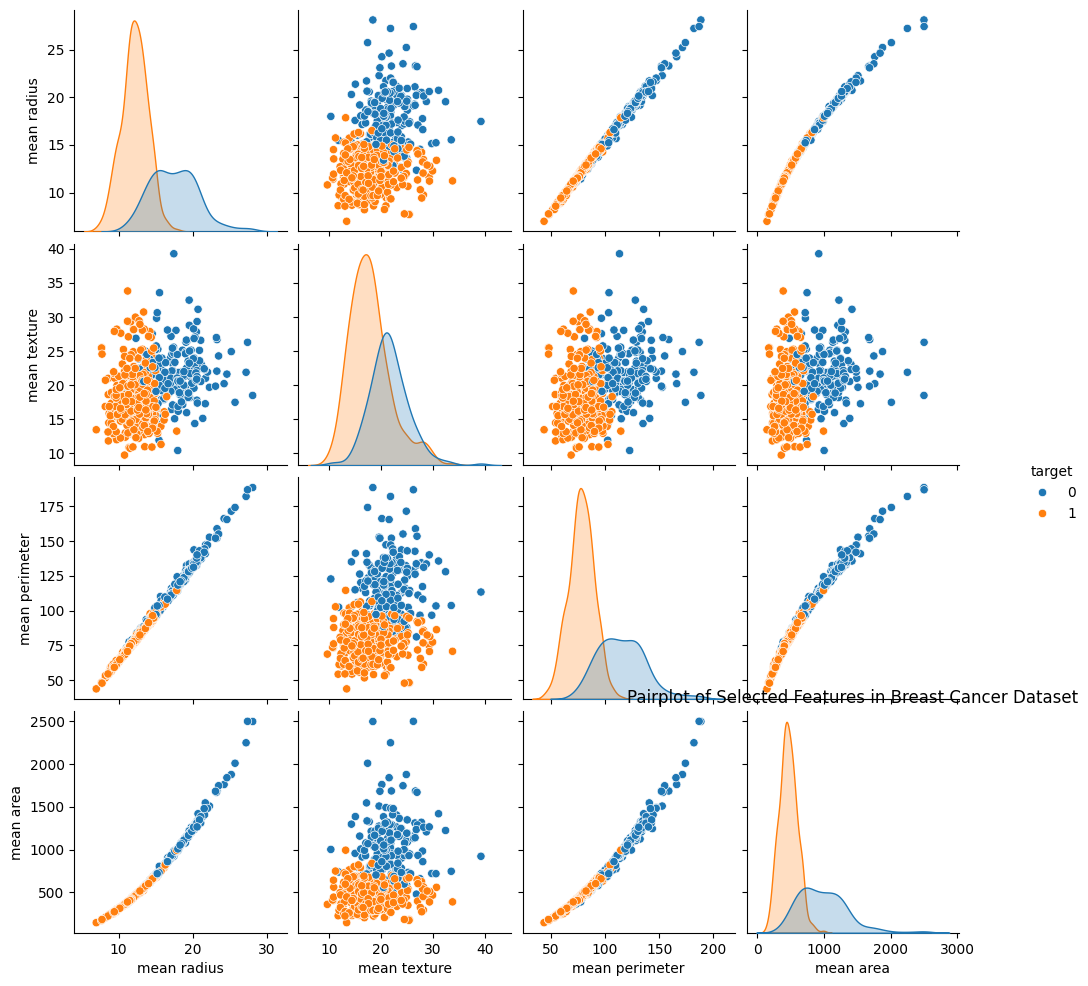

In [15]:
# Create a pairplot to visualize relationships between selected features
sns.pairplot(
    df,

    # Color the observations based on their target class (here 2)
    hue='target',

    # Choose the features we want to visualize
    vars=['mean radius', 'mean texture', 'mean perimeter', 'mean area']
)
plt.title('Pairplot of Selected Features in Breast Cancer Dataset')

# Display the plot
plt.show()


__On the diagonal:__ Shows the distribution of ONE feature. Seaborn uses a curve/histogram to show how the values are distributed.

__Off the diagonal:__ Shows the relationship between TWO features. Each observation is shown as a point, so these are scatterplots.

__What should we look for in these plots?__

Whethere classes are separable in a plot! If orange and blue dots cleanly cluster separately, the coresponding features are the most usefule. This guides feature selection.

__Example__ Scatter Plot of mean area vs mean texture (last row, second plot from left).

The plot shows clear separation. Orange dots are located around bottom-center. So they have small values of radius (0,1000) and texture (10-30). Blue dots are located around top-center.

Practical meaning: Imagine you measure a patient's tumor: mean area = 1500, and mean tenture = 20. This patient's tumor is likely not cancerous (BENIGN).




## 2. **Binary Classification Using Logistic Regression**


**Logistic Regression Overview:**

Logistic regression models the probability that an observation, based on its features, belongs to a particular category (target).

Recall that in the breast cancer dataset, the target variable is binary, indicating whether the tumor is malignant (encoded as 1) or benign (encoded as 0).

For example, we can represent the target variable $ Y$ as follows:
$$
Y =
\begin{cases}
0 & \text{if malignant} \\
1 & \text{if benign}
\end{cases}
$$


So for example the probability that the tumor is malignant, given its measurements, can be expressed as:

$$
p(X) = \Pr(Y = 0 | X)
$$
where $X$ represents the measurements.

Equivalently, the probability that the tumor is bening, given its measurements, is:

$$
p(X) = \Pr(Y = 1 | X)
$$

To model this relationship, we can use a linear regression approach to fit $Y$ against $X$. Then we apply the **logistic function (sigmoid)** to the output of the linear regression. The logistic function maps the linear regression output to a range between 0 and 1, which can then be interpreted as a probability.

Here is the formula:
$$
p(X) = \frac{1}{1 + e^{-(\beta_0 + \beta_1X)}} \quad \quad (*)
$$

where $\beta_0$ and $\beta_1$ are the coefficients of the simple linear regresstion.

####**Logestic Regression for Breast Cancer Dataset**

In [24]:
featurs = data.feature_names
print(featurs)

['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']


In [25]:
# Select features and target
X = df[featurs]  # All features
y = df['target']  # Target variable

In [26]:
# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [27]:
# Initialize and fit logistic regression model
#max_iter sets maximum number of iterations the algorithm is allowed to use to find the model's best parameters.


model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=10000)

In [28]:
# Make predictions
y_pred = model.predict(X_test)

In [29]:
# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.956140350877193


Recall that in linear regression, we used RMSE as a measure of accuracy. For classification, we count how many predictions were correct. For example, accuracy of 0.95% means 95 out of 100 observations were classified corectly.  

Now, let's create a new data point to classify. For example, let’s say we want to predict whether a tumor is malignant or benign based on the following features (scaled measurements):

In [30]:
# Get the feature names from the dataset
feature_names = data.feature_names

# Create a new data point with 30 features
new_data = pd.DataFrame([[14.0, 20.0, 85.0, 550.0, 0.1,
                          0.2, 0.3, 0.4, 0.5, 0.1,
                          0.2, 0.3, 0.4, 0.5, 0.6,
                          0.7, 0.8, 0.9, 1.0, 1.1,
                          1.2, 1.3, 1.4, 1.5, 1.6,
                          1.7, 1.8, 1.9, 2.0, 2.1]],
                        columns=feature_names)

In [31]:
# Get the predicted probabilities
proba = model.predict_proba(new_data)

# The output will contain two probabilities:
# - proba[0][0] is the probability of class 0 (Benign)
# - proba[0][1] is the probability of class 1 (Malignant)

print(f"Probability of Benign: {proba[0][0]}")
print(f"Probability of Malignant: {proba[0][1]}")


Probability of Benign: 1.234932156535251e-10
Probability of Malignant: 0.9999999998765068


If the predicted probability is greater than or equal to 0.5, the model predicts class 1 (Malignant).
If the predicted probability is less than 0.5, the model predicts class 0 (Benign). So the predicted tumor for this new data is Malignant.

Alternatively, we could do this directly:

In [32]:
# Make a prediction
prediction = model.predict(new_data)

# Interpret the prediction
if prediction[0] == 0:
    print("The predicted tumor is Benign.")
else:
    print("The predicted tumor is Malignant.")


The predicted tumor is Malignant.


**Group work: Feature Selection Experiment**

Part 1: Run the code with 3 different feature sets and record accuracies in a table

   1.  Original 4 features

   2.  4 "worst" features  
  
   3.  All 30 features




Part 2: Answer these questions:
   1. Which feature set had the BEST accuracy? Why?
   
   2. Did removing features hurt accuracy?
      (Original 4 vs All 30)
   
   3. Did changing which 4 features improve accuracy?
      (Original 4 vs Different 4)
   
Part 4: Pick any 4 features you want to improve the accuracy, if possible at all!
  